In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('./Data/global_cancer_patients_2015_2024 (1).csv')

In [3]:
df.head()

,Patient_ID,Age,Gender,Country_Region,Year,Genetic_Risk,Air_Pollution,Alcohol_Use,Smoking,Obesity_Level,Cancer_Type,Cancer_Stage,Treatment_Cost_USD,Survival_Years,Target_Severity_Score
0,PT0000000,71,Male,UK,2021,6.4,2.8,9.5,0.9,8.7,Lung,Stage III,62913.44,5.9,4.92
1,PT0000001,34,Male,China,2021,1.3,4.5,3.7,3.9,6.3,Leukemia,Stage 0,12573.41,4.7,4.65
2,PT0000002,80,Male,Pakistan,2023,7.4,7.9,2.4,4.7,0.1,Breast,Stage II,6984.33,7.1,5.84
3,PT0000003,40,Male,UK,2015,1.7,2.9,4.8,3.5,2.7,Colon,Stage I,67446.25,1.6,3.12
4,PT0000004,43,Female,Brazil,2017,5.1,2.8,2.3,6.7,0.5,Skin,Stage III,77977.12,2.9,3.62


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Patient_ID             50000 non-null  str    
 1   Age                    50000 non-null  int64  
 2   Gender                 50000 non-null  str    
 3   Country_Region         50000 non-null  str    
 4   Year                   50000 non-null  int64  
 5   Genetic_Risk           50000 non-null  float64
 6   Air_Pollution          50000 non-null  float64
 7   Alcohol_Use            50000 non-null  float64
 8   Smoking                50000 non-null  float64
 9   Obesity_Level          50000 non-null  float64
 10  Cancer_Type            50000 non-null  str    
 11  Cancer_Stage           50000 non-null  str    
 12  Treatment_Cost_USD     50000 non-null  float64
 13  Survival_Years         50000 non-null  float64
 14  Target_Severity_Score  50000 non-null  float64
dtypes: float64(8)

In [5]:
df.duplicated().sum()


np.int64(0)

## 2. Age Distribution Analysis

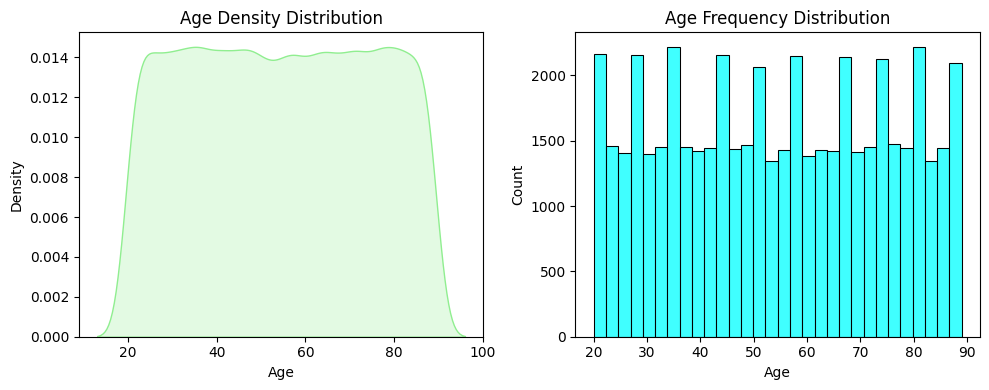

In [6]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.kdeplot(df["Age"], fill=True, color="lightgreen")
plt.title("Age Density Distribution")
plt.xlabel("Age")
plt.ylabel("Density")

plt.subplot(1,2,2)
sns.histplot(df["Age"], bins=30,  kde=False, color="cyan")
plt.title("Age Frequency Distribution")
plt.xlabel("Age")
plt.ylabel("Count")

plt.tight_layout()

## 3. Gender Distribution

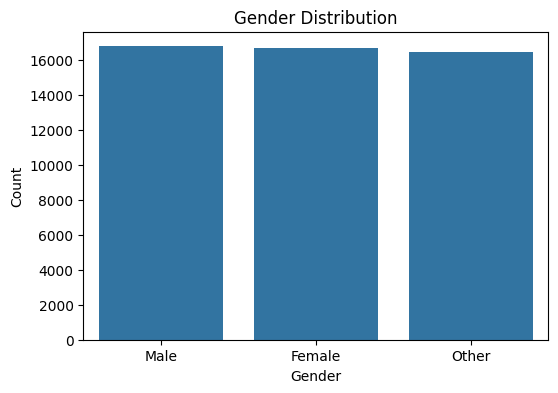

In [7]:
plt.figure(figsize=(6,4))
sns.countplot(x="Gender", data=df)
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

## 4. Country Distribution 

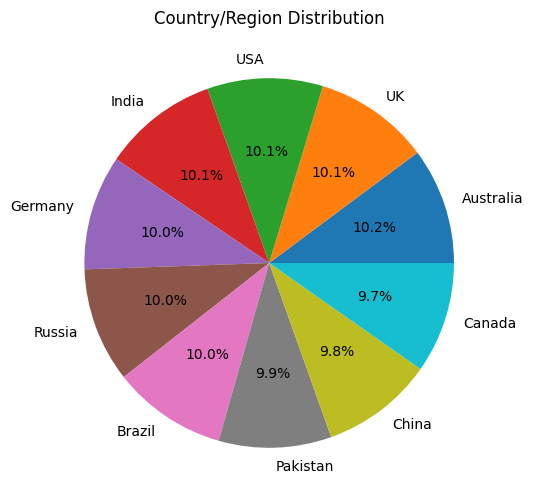

In [8]:
country_counts = df["Country_Region"].value_counts()

plt.figure(figsize=(6,6))
plt.pie(country_counts.values,
        labels=country_counts.index,
        autopct='%1.1f%%')

plt.title("Country/Region Distribution")
plt.show()

## 5. Cancer Type Distribution 

C:\Users\aayad\AppData\Local\Temp\ipykernel_10252\2609006732.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cancer_counts.index,y=cancer_counts.values, palette=color)
C:\Users\aayad\AppData\Local\Temp\ipykernel_10252\2609006732.py:5: UserWarning: 
The palette list has fewer values (7) than needed (8) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(x=cancer_counts.index,y=cancer_counts.values, palette=color)


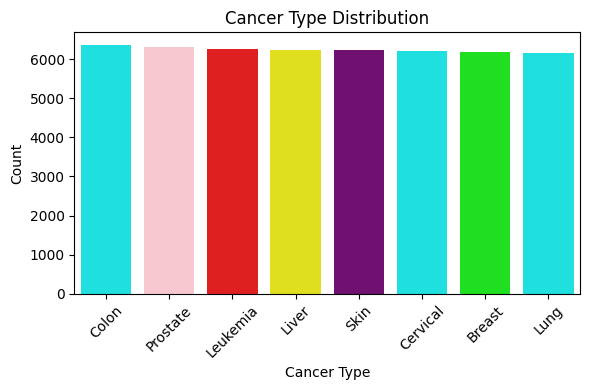

In [9]:
cancer_counts = df["Cancer_Type"].value_counts()

plt.figure(figsize=(6,4))
color = ["aqua", "pink", "red", "yellow" , 'purple', 'cyan', 'lime']
sns.barplot(x=cancer_counts.index,y=cancer_counts.values, palette=color)

plt.title("Cancer Type Distribution")
plt.xlabel("Cancer Type")
plt.ylabel("Count")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 6. Cancer Stage Distribution

C:\Users\aayad\AppData\Local\Temp\ipykernel_10252\538811635.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=stage_counts.index,y=stage_counts.values, palette=color)
C:\Users\aayad\AppData\Local\Temp\ipykernel_10252\538811635.py:5: UserWarning: The palette list has more values (6) than needed (5), which may not be intended.
  sns.barplot(x=stage_counts.index,y=stage_counts.values, palette=color)


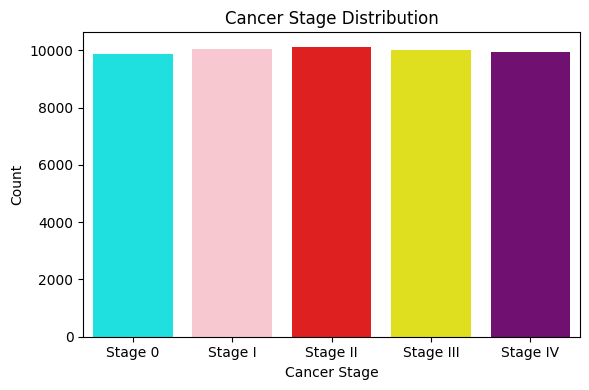

In [10]:
stage_counts = df["Cancer_Stage"].value_counts().sort_index()

plt.figure(figsize=(6,4))
color = ["aqua", "pink", "red", "yellow" , 'purple', 'cyan']
sns.barplot(x=stage_counts.index,y=stage_counts.values, palette=color)

plt.title("Cancer Stage Distribution")
plt.xlabel("Cancer Stage")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

## 7. Treatment Cost Distribution 

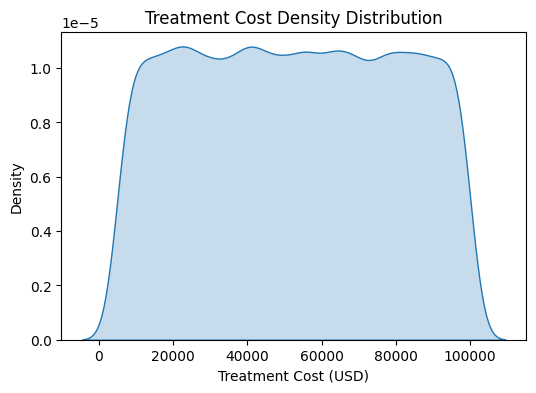

In [11]:
plt.figure(figsize=(6,4))
sns.kdeplot(df["Treatment_Cost_USD"], fill=True)
plt.title("Treatment Cost Density Distribution")
plt.xlabel("Treatment Cost (USD)")
plt.ylabel("Density")
plt.show()


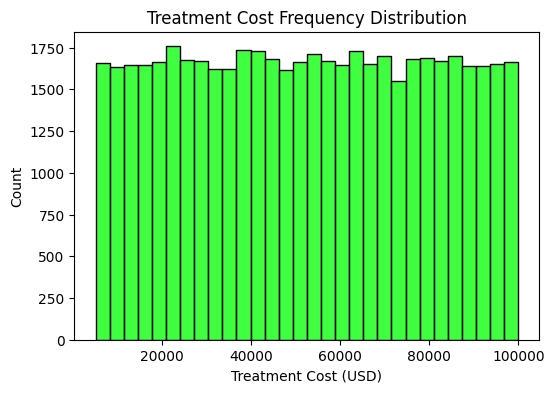

In [12]:
plt.figure(figsize=(6,4))
sns.histplot(df["Treatment_Cost_USD"], bins=30, color= 'lime')
plt.title("Treatment Cost Frequency Distribution")
plt.xlabel("Treatment Cost (USD)")
plt.ylabel("Count")
plt.show()


In [13]:
df["Treatment_Cost_USD"].describe()
df["Treatment_Cost_USD"].skew()

np.float64(0.004063624207520141)

## 8. Risk Factor Summary

In [14]:
coi = ['Genetic_Risk','Air_Pollution','Alcohol_Use','Smoking','Obesity_Level']
summ = df[coi].agg(['mean','std','min','max'])
summ

,Genetic_Risk,Air_Pollution,Alcohol_Use,Smoking,Obesity_Level
mean,5.001698,5.010126,5.010880,4.989826,4.991176
std,2.885773,2.888399,2.888769,2.881579,2.894504
min,0.000000,0.000000,0.000000,0.000000,0.000000
max,10.000000,10.000000,10.000000,10.000000,10.000000


## 9. Risk Factors vs Severity (Regression Analysis)

In [15]:
from scipy.stats import linregress

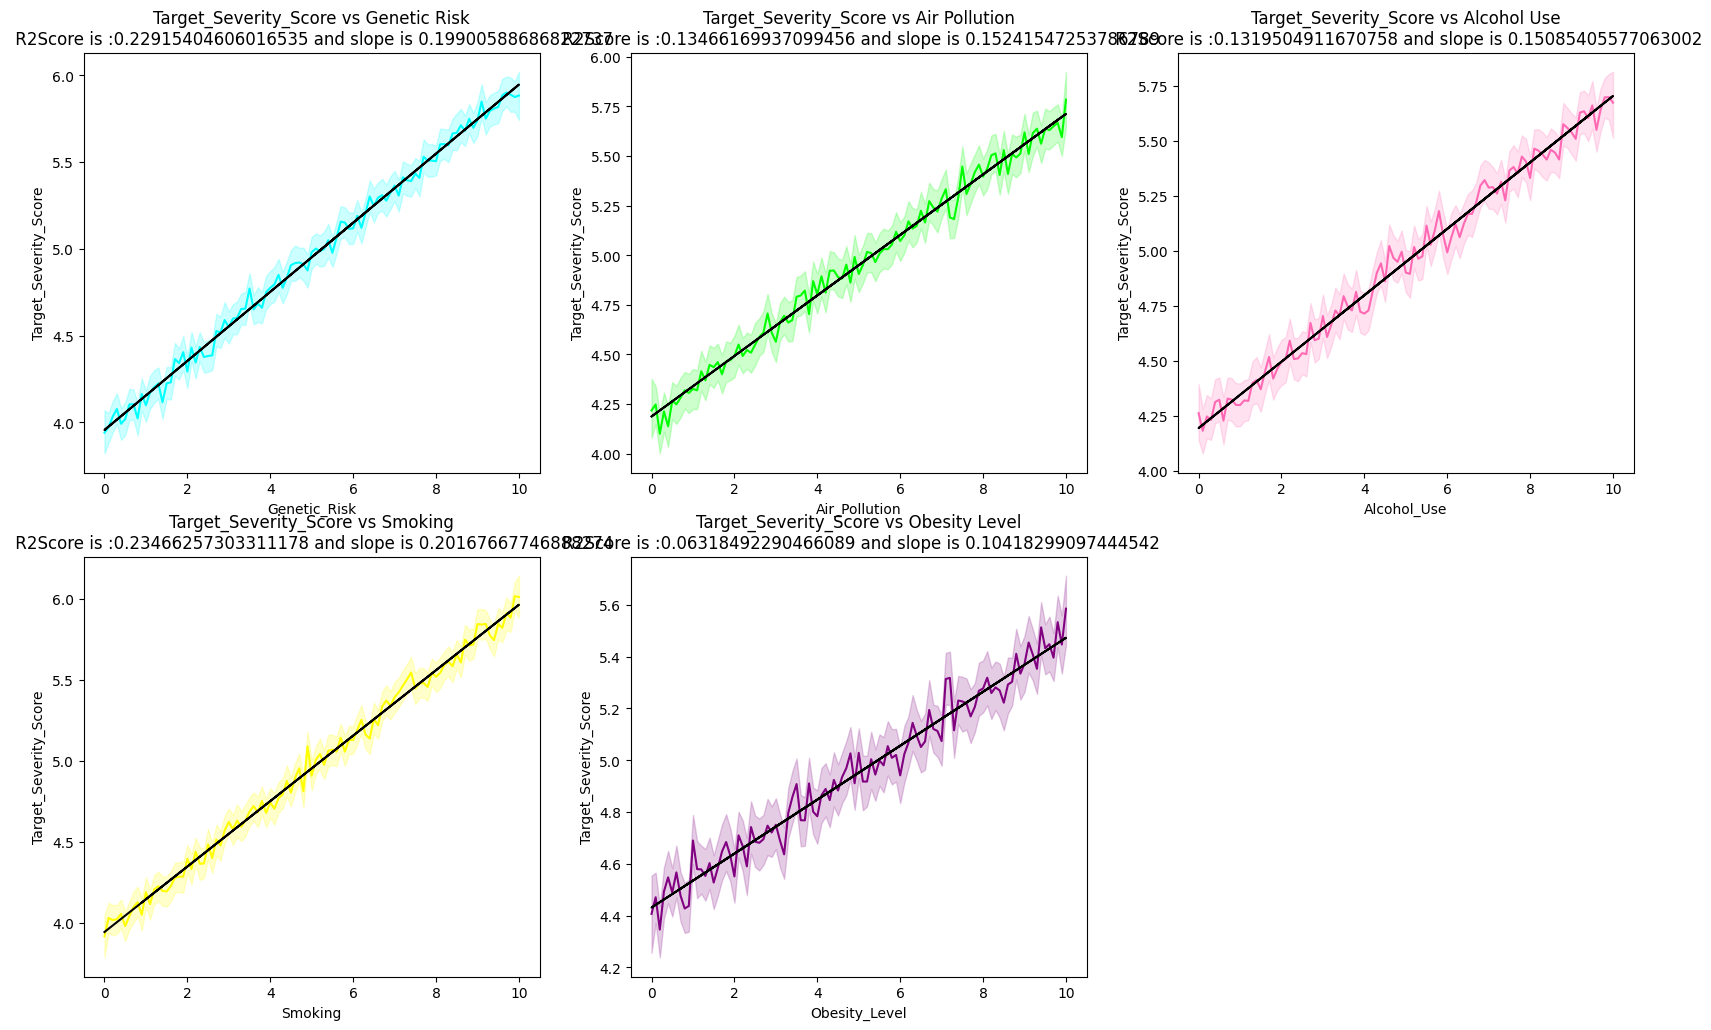

In [16]:
risk_factors= ['Genetic_Risk','Air_Pollution', 'Alcohol_Use', 'Smoking', 'Obesity_Level']
titles = ['Genetic Risk','Air Pollution', 'Alcohol Use', 'Smoking', 'Obesity Level']
colors = ['aqua','lime','hotpink','yellow','purple']

plt.figure(figsize=(20,12))
for i,(factor,title,color) in enumerate(zip(risk_factors,titles,colors),1):
    plt.subplot(2,3,i)
    x = df[factor]
    y = df['Target_Severity_Score']

    slope, intrcpt , r_value, p_value, stderr = linregress(x,y)
    r2_score = r_value**2
    sns.lineplot(x = x,y= y,data= df,color = color)
    plt.plot(x,slope*x +intrcpt,color = 'black' , label = 'Regression Line')
    plt.title(f'Target_Severity_Score vs {title}\n R2Score is :{r2_score} and slope is {slope}')

In [17]:
result = linregress(x, y)

print("Slope:", result.slope)
print("Intercept:", result.intercept)
print("R-value:", result.rvalue)
print("R-squared:", result.rvalue**2)
print("P-value:", result.pvalue)

Slope: 0.10418299097444542
Intercept: 4.431211755840131
R-value: 0.25136611327834324
R-squared: 0.06318492290466089
P-value: 0.0


## 10.  Proportion of Early-Stage Diagnosis by Cancer Type

In [18]:
stage_count = df[df['Cancer_Type'] == 'Lung']['Cancer_Stage'].value_counts()
early_stage_count = stage_count.get('Stage 0',0) + stage_count.get('Stage I',0)
total_sum = stage_count.sum()
(early_stage_count / total_sum)*100

np.float64(38.43156356551388)

In [19]:
cancer_types = df["Cancer_Type"].unique()

for cancer in cancer_types:
    stage_count = df[df["Cancer_Type"] == cancer]["Cancer_Stage"].value_counts()
    early_stage_count = stage_count.get("Stage 0", 0) + stage_count.get("Stage I", 0)
    total_sum = stage_count.sum()
    percentage = (early_stage_count / total_sum) * 100
    print(cancer, percentage)

Lung 38.43156356551388
Leukemia 39.53080114905841
Breast 39.47325900791727
Colon 40.41718946047679
Skin 40.41084898090194
Cervical 39.85856637737062
Prostate 40.187064045656314
Liver 40.614498319731155


## 11. Identifying Key Predictors of Cancer Severity & Survival

In [20]:
factor = ['Age','Genetic_Risk','Air_Pollution','Alcohol_Use','Smoking','Obesity_Level']
Target = ['Target_Severity_Score','Survival_Years']

pear_corr = df[factor + Target].corr(method='pearson')
spearman_corr = df[factor + Target].corr(method='spearman')

pear_res = pear_corr[Target]
spear_res = spearman_corr[Target]

pd.concat([pear_res, spear_res], axis=1, keys=['Pearson','Spearman'])

Pearson                 \
                      Target_Severity_Score Survival_Years   
Age                               -0.001481      -0.000147   
Genetic_Risk                       0.478700       0.001708   
Air_Pollution                      0.366963       0.000893   
Alcohol_Use                        0.363250      -0.000527   
Smoking                            0.484420       0.001371   
Obesity_Level                      0.251366       0.009771   
Target_Severity_Score              1.000000       0.004161   
Survival_Years                     0.004161       1.000000   

                                   Spearman                 
                      Target_Severity_Score Survival_Years  
Age                               -0.002076      -0.000149  
Genetic_Risk                       0.472193       0.001684  
Air_Pollution                      0.357528       0.000841  
Alcohol_Use                        0.354694      -0.000543  
Smoking                            0.477881       0.001372  
Obesity_Level                      0.243152       0.009780  
Target_Severity_Score              1.000000       0.003431  
Survival_Years                     0.003431       1.000000

## Day 3 Task
## 1: Multivariate Severity Analysis (Not Just One Factor)

In [21]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [22]:
X = df[factor]
y = df['Target_Severity_Score']
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)
r2 = r2_score(y, y_pred)
print("R square Score", r2)

R square Score 0.7919319966566292


In [23]:
n = X.shape[0]
p = X.shape[1]
adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
print("Adjusted R square", adjusted_r2)

Adjusted R square 0.791907025000196


In [24]:
coeff_table = pd.DataFrame({'Feature': factor,'Coefficient': model.coef_})
coeff_table

,Feature,Coefficient
0,Age,-0.000098
1,Genetic_Risk,0.200469
2,Air_Pollution,0.151419
3,Alcohol_Use,0.150678
4,Smoking,0.201743
5,Obesity_Level,0.100207


## 2: Survival Prediction Analysis


In [25]:
features = ['Age','Genetic_Risk','Air_Pollution','Alcohol_Use','Smoking','Obesity_Level']
X = df[features]

In [26]:
y_severity = df['Target_Severity_Score']

m_severity = LinearRegression()
m_severity.fit(X, y_severity)

y_sev = m_severity.predict(X)

r2 = r2_score(y_severity, y_sev)
print("Severity R squared:", r2)


Severity R squared: 0.7919319966566292


In [27]:
sev_imp = pd.DataFrame({
    'Feature': features,
    'Coefficient': m_severity.coef_
})

sev_imp = sev_imp.sort_values(by='Coefficient', ascending=False)
sev_imp

,Feature,Coefficient
4,Smoking,0.201743
1,Genetic_Risk,0.200469
2,Air_Pollution,0.151419
3,Alcohol_Use,0.150678
5,Obesity_Level,0.100207
0,Age,-0.000098


In [28]:
y_survival = df['Survival_Years']

survival = LinearRegression()
survival.fit(X, y_survival)

y_sur = survival.predict(X)

r2 = r2_score(y_survival, y_sur)
print("Survival R square:", r2)


Survival R square: 0.00010108207312509165


In [29]:
sur_importance = pd.DataFrame({
    'Feature': features,
    'Coefficient': survival.coef_
})

sur_imp = sur_importance.sort_values(by='Coefficient', ascending=False)
sur_imp


,Feature,Coefficient
5,Obesity_Level,0.009718
1,Genetic_Risk,0.001680
4,Smoking,0.001317
2,Air_Pollution,0.000833
0,Age,-0.000019
3,Alcohol_Use,-0.000594


In [30]:
print("Top 3 Predictors for Severity:")
print(sev_imp.head(3))

print("\nTop 3 Predictors for Survival:")
sur_imp.head(3)

Top 3 Predictors for Severity:
         Feature  Coefficient
4        Smoking     0.201743
1   Genetic_Risk     0.200469
2  Air_Pollution     0.151419

Top 3 Predictors for Survival:


,Feature,Coefficient
5,Obesity_Level,0.009718
1,Genetic_Risk,0.001680
4,Smoking,0.001317


## 3: Cancer Type Risk Profiling

In [31]:
severity_avg = df.groupby("Cancer_Type")["Target_Severity_Score"].mean().reset_index()
severity_avg = severity_avg.sort_values(by="Target_Severity_Score", ascending=False)
severity_avg

,Cancer_Type,Target_Severity_Score
7,Skin,4.969957
3,Leukemia,4.967952
4,Liver,4.964380
1,Cervical,4.951461
0,Breast,4.947764
6,Prostate,4.943358
5,Lung,4.937604
2,Colon,4.927520


In [32]:
survival_avg = df.groupby("Cancer_Type")["Survival_Years"].mean().reset_index()
survival_avg = survival_avg.sort_values(by="Survival_Years")
survival_avg

,Cancer_Type,Survival_Years
7,Skin,4.975060
0,Breast,4.975295
5,Lung,4.987303
3,Leukemia,5.005538
6,Prostate,5.020054
4,Liver,5.024404
2,Colon,5.027368
1,Cervical,5.035583


In [33]:
print("Cancer Type with Highest Average Severity:")
severity_avg.head(1)

Cancer Type with Highest Average Severity:


,Cancer_Type,Target_Severity_Score
7,Skin,4.969957


In [34]:
print("Cancer Type with Lowest Average Survival:")
survival_avg.head(1)

Cancer Type with Lowest Average Survival:


,Cancer_Type,Survival_Years
7,Skin,4.97506


C:\Users\aayad\AppData\Local\Temp\ipykernel_10252\3451656145.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Cancer_Type", y="Target_Severity_Score", data=severity_avg, palette=colors)
C:\Users\aayad\AppData\Local\Temp\ipykernel_10252\3451656145.py:3: UserWarning: 
The palette list has fewer values (7) than needed (8) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(x="Cancer_Type", y="Target_Severity_Score", data=severity_avg, palette=colors)


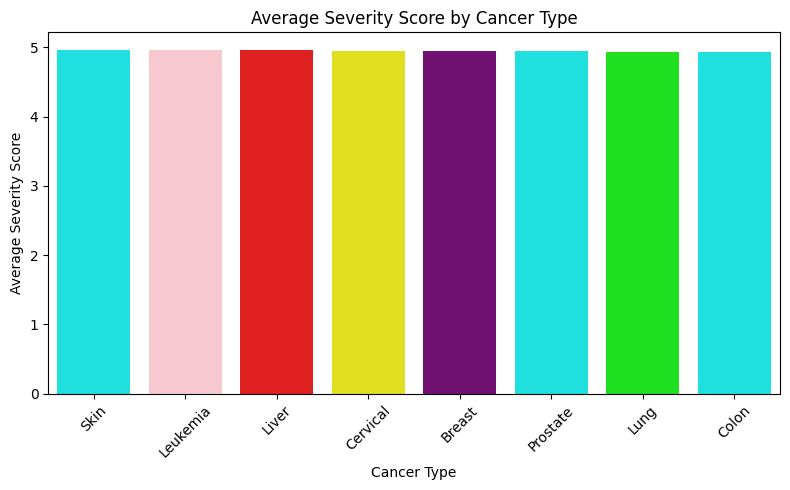

In [35]:
plt.figure(figsize=(8,5))
colors = ["aqua", "pink", "red", "yellow" , 'purple', 'cyan', 'lime']
sns.barplot(x="Cancer_Type", y="Target_Severity_Score", data=severity_avg, palette=colors)
plt.title("Average Severity Score by Cancer Type")
plt.xlabel("Cancer Type")
plt.ylabel("Average Severity Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

C:\Users\aayad\AppData\Local\Temp\ipykernel_10252\1684144850.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Cancer_Type", y="Survival_Years", data=survival_avg, palette=colors)
C:\Users\aayad\AppData\Local\Temp\ipykernel_10252\1684144850.py:3: UserWarning: 
The palette list has fewer values (7) than needed (8) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(x="Cancer_Type", y="Survival_Years", data=survival_avg, palette=colors)


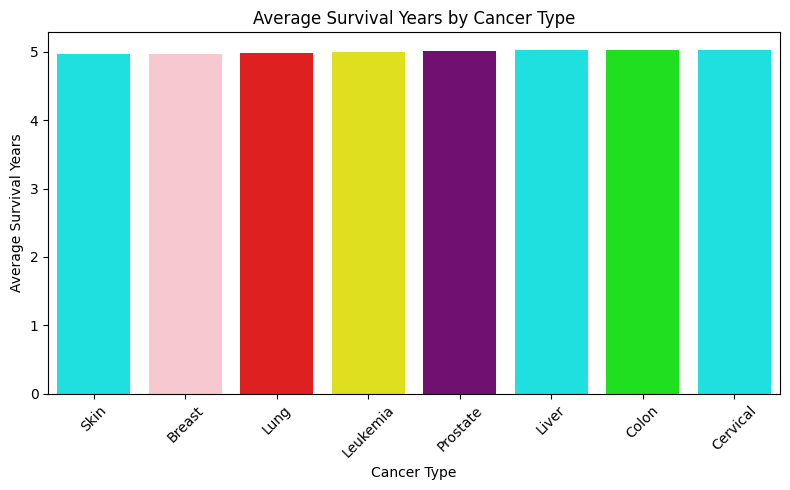

In [36]:
plt.figure(figsize=(8,5))
colors = ["aqua", "pink", "red", "yellow" , 'purple', 'cyan', 'lime']
sns.barplot(x="Cancer_Type", y="Survival_Years", data=survival_avg, palette=colors)
plt.title("Average Survival Years by Cancer Type")
plt.xlabel("Cancer Type")
plt.ylabel("Average Survival Years")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 4: Early Stage Detection Efficiency (All Cancer Types) 

In [37]:
results = []
for cancer in df["Cancer_Type"].unique():
    cancer_data = df[df["Cancer_Type"] == cancer]
    total_cases = len(cancer_data)
    stage_counts = cancer_data["Cancer_Stage"].value_counts()
    early_stage = stage_counts.get("Stage 0", 0) + stage_counts.get("Stage I", 0)
    percentage = (early_stage / total_cases) * 100
    results.append([cancer, percentage])

In [38]:
early_stage = pd.DataFrame(results,columns=["Cancer_Type", "Early_Stage_%"])

In [39]:
early_stage = early_stage.sort_values(by="Early_Stage_%",ascending=False)
early_stage

,Cancer_Type,Early_Stage_%
7,Liver,40.614498
3,Colon,40.417189
4,Skin,40.410849
6,Prostate,40.187064
5,Cervical,39.858566
1,Leukemia,39.530801
2,Breast,39.473259
0,Lung,38.431564


## 5: Cost vs Survival Analysis

In [40]:
correlation = df[['Treatment_Cost_USD', 'Survival_Years']].corr(method='pearson')
correlation

,Treatment_Cost_USD,Survival_Years
Treatment_Cost_USD,1.000000,-0.000429
Survival_Years,-0.000429,1.000000


In [41]:
from scipy.stats import linregress

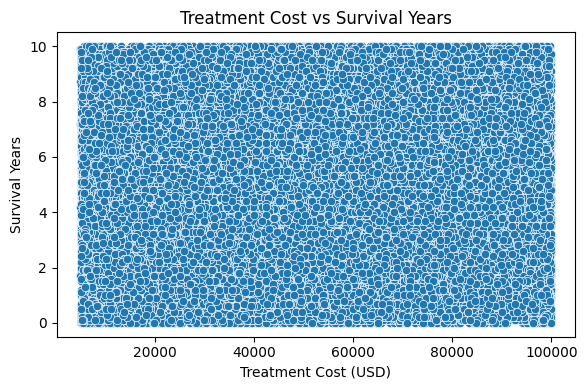

In [42]:
x = df['Treatment_Cost_USD']
y = df['Survival_Years']
plt.figure(figsize=(6,4))
sns.scatterplot(x=x, y=y)
plt.title("Treatment Cost vs Survival Years")
plt.xlabel("Treatment Cost (USD)")
plt.ylabel("Survival Years")
plt.tight_layout()
plt.show()

In [43]:
slope, intercept, r_value, p_value, std_err = linregress(x, y)
print("Slope:", slope)
print("R square:", r_value**2)
print("P-value:", p_value)

Slope: -4.52475799338934e-08
R square: 1.8438902185535282e-07
P-value: 0.9235082012963105


## DAY-4 Task

# Evaluate if higher cancer stages lead to greater treatment costs and reduced survival years

In [44]:
df.groupby("Cancer_Stage")["Treatment_Cost_USD"].mean()

Cancer_Stage
Stage 0      52572.589493
Stage I      52674.079638
Stage II     52082.841258
Stage III    52708.197506
Stage IV     52302.471041
Name: Treatment_Cost_USD, dtype: float64

In [45]:
df.groupby("Cancer_Stage")["Survival_Years"].mean()

Cancer_Stage
Stage 0      5.015199
Stage I      5.012990
Stage II     4.995170
Stage III    5.036311
Stage IV     4.972596
Name: Survival_Years, dtype: float64